In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))

# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [2]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds')

In [3]:
neuron = subset(seurat, Class == 'Neuron')
neuron

An object of class Seurat 
39743 features across 8883 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declari

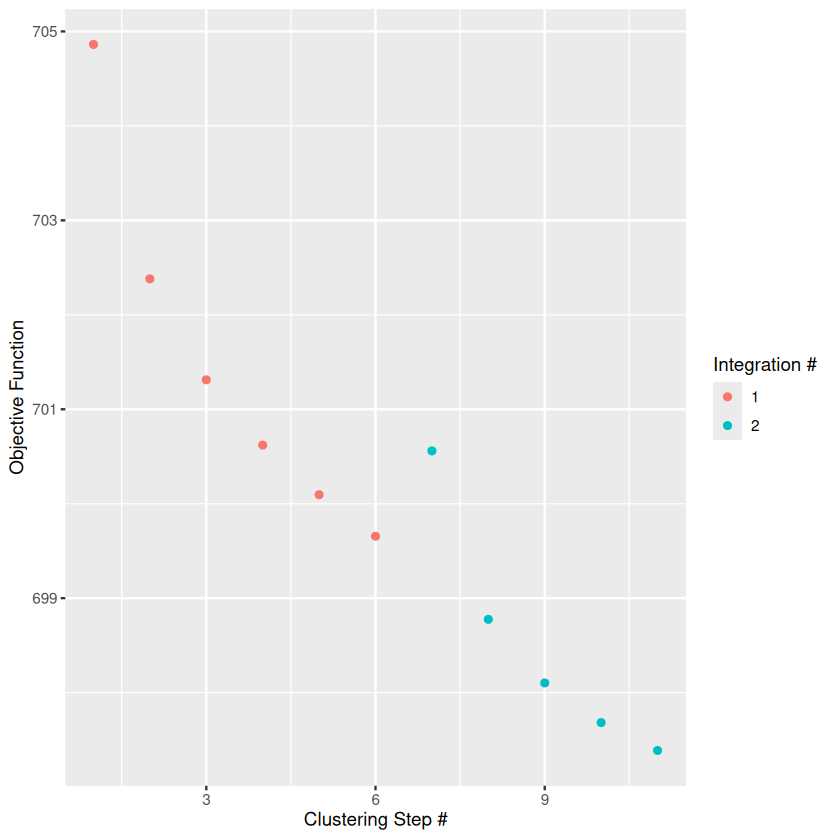

In [4]:
class_resolution = 0.5

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = neuron@assays$RNA$counts
meta = neuron@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_1 = CreateSeuratObject(counts = new_assay)
neuron_1 = AddMetaData(neuron_1, meta)

neuron_1 = NormalizeData(neuron_1, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_1 = FindVariableFeatures(neuron_1, selection.method = "vst", nfeatures = 3000)
neuron_1 = ScaleData(neuron_1, features = rownames(neuron_1))

neuron_1 = neuron_1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

neuron_1 = RunHarmony(
    neuron_1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

neuron_1 = neuron_1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

In [46]:
df2$subclass_name %>% unique()

[1] "327 Oligo NN"                          
  [2] "321 Astroependymal NN"                 
  [3] "202 PRT Tcf7l2 Gaba"                   
  [4] "318 Astro-NT NN"                       
  [5] "135 STN-PSTN Pitx2 Glut"               
  [6] "159 IF-RL-CLI-PAG Foxa1 Glut"          
  [7] "232 LDT Vsx2 Nkx6-1 Nfib Glut"         
  [8] "229 PB-NTS Phox2b Ebf3 Lmx1b Glut"     
  [9] "007 L2/3 IT CTX Glut"                  
 [10] "326 OPC NN"                            
 [11] "330 VLMC NN"                           
 [12] "224 PCG-PRNr Vsx2 Nkx6-1 Glut"         
 [13] "141 PH-SUM Foxa1 Glut"                 
 [14] "320 Astro-OLF NN"                      
 [15] "155 PRC-PAG Pax6 Glut"                 
 [16] "334 Microglia NN"                      
 [17] "138 PH Pitx2 Glut"                     
 [18] "338 Lymphoid NN"                       
 [19] "322 Tanycyte NN"                       
 [20] "333 Endo NN"                           
 [21] "215 SNc-VTA-RAmb Foxa1 Dopa"           
 [22] "243 PGRN-PARN-MDRN Hoxb5 Glut"         
 [23] "319 Astro-TE NN"                       
 [24] "081 ACB-BST-FS D1 Gaba"                
 [25] "337 DC NN"                             
 [26] "177 SCig-an-PPT Foxb1 Glut"            
 [27] "335 BAM NN"                            
 [28] "254 VCO Mafa Meis2 Glut"               
 [29] "045 OB-STR-CTX Inh IMN"                
 [30] "213 SCsg Gabrr2 Gaba"                  
 [31] "160 PAG-SC Neurod2 Meis2 Glut"         
 [32] "170 PAG-MRN Tfap2b Glut"               
 [33] "231 IPN-LDT Vsx2 Nkx6-1 Glut"          
 [34] "097 PVHd-SBPV Six3 Prox1 Gaba"         
 [35] "165 PAG-MRN Pou3f1 Glut"               
 [36] "323 Ependymal NN"                      
 [37] "093 RT-ZI Gnb3 Gaba"                   
 [38] "171 PAG Pou4f1 Bnc2 Glut"              
 [39] "078 SI-MA-ACB Ebf1 Bnc2 Gaba"          
 [40] "192 PPN-CUN-PCG Otp En1 Gaba"          
 [41] "166 MRN Pou3f1 C1ql4 Glut"             
 [42] "196 PAG-PPN Pax5 Sox21 Gaba"           
 [43] "217 PB Lmx1a Glut"                     
 [44] "157 RN Spp1 Glut"                      
 [45] "101 ZI Pax6 Gaba"                      
 [46] "136 PMv-TMv Pitx2 Glut"                
 [47] "198 IC Six3 En2 Gaba"                  
 [48] "006 L4/5 IT CTX Glut"                  
 [49] "168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut"
 [50] "209 SCs Pax7 Nfia Gaba"                
 [51] "103 PVHd-DMH Lhx6 Gaba"                
 [52] "206 SCm-PAG Cdh23 Gaba"                
 [53] "194 MRN-VTN-PPN Pax5 Cdh23 Gaba"       
 [54] "158 MRN-PAG Nkx6-1 Glut"               
 [55] "057 NDB-SI-MA-STRv Lhx8 Gaba"          
 [56] "086 MPO-ADP Lhx8 Gaba"                 
 [57] "181 IC Tfap2d Maf Glut"                
 [58] "277 DTN-LDT-IPN Otp Pax3 Gaba"         
 [59] "199 PAG-MRN-RN Foxa2 Gaba"             
 [60] "195 SNr-VTA Pax5 Npas1 Gaba"           
 [61] "331 Peri NN"                           
 [62] "085 SI-MPO-LPO Lhx8 Gaba"              
 [63] "169 PAG-SC Pou4f1 Zic1 Glut"           
 [64] "285 MY Lhx1 Gly-Gaba"                  
 [65] "201 PAG-RN Nkx2-2 Otx1 Gaba"           
 [66] "156 MB-ant-ve Dmrta2 Glut"             
 [67] "180 SCiw Pitx2 Glut"                   
 [68] "038 DG-PIR Ex IMN"                     
 [69] "332 SMC NN"                            
 [70] "161 PAG Pou4f3 Glut"                   
 [71] "190 ND-INC Foxd2 Glut"                 
 [72] "092 TMv-PMv Tbx3 Hist-Gaba"            
 [73] "167 PRC-PAG Tcf7l2 Irx2 Glut"          
 [74] "173 PAG Pou4f2 Glut"                   
 [75] "134 PH-ant-LHA Otp Bsx Glut"           
 [76] "114 COAa-PAA-MEA Barhl2 Glut"          
 [77] "163 APN C1ql2 Glut"                    
 [78] "205 SC-PAG Lef1 Emx2 Gaba"             
 [79] "221 LDT-PCG Vsx2 Lhx4 Glut"            
 [80] "107 DMH Hmx2 Gaba"                     
 [81] "329 ABC NN"                            
 [82] "264 PRNc Otp Gly-Gaba"                 
 [83] "139 PH-LHA Foxb1 Glut"                 
 [84] "268 CS-PRNr-DR En1 Sox2 Gaba"          
 [85] "276 LDT-PCG St18 Gaba"                 
 [86] "

### Neuron clustering

In [ ]:
neuron_2 = neuron_1
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/IP-VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/VTA_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$class_name, df2$class_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(neuron_2)]
neuron_2$Mouse_anno = matched_anno

In [ ]:
table(neuron_2$Mouse_anno, neuron_2$seurat_clusters)


                   
                      0   1   2   3   4   5   6   7   8   9  10  11  12  13  14
  01 IT-ET Glut       0   0   0   0   0   0   0   0   0   0   0   0   0   0   1
  02 NP-CT-L6b Glut   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  06 CTX-CGE GABA     3   6   0   0   0   0   0   0   0   0   0   0   0   0   1
  07 CTX-MGE GABA     1   5   0   0   0   0   0   0   0   0   0   0   0   0   0
  08 CNU-MGE GABA     0  18   0   0   0   0   0   0   0   0   0   0   0   0   0
  09 CNU-LGE GABA     1   0   0   0   0   0   0   0   0   0   0   1   0   0   0
  11 CNU-HYa GABA    12  19  11   2   1   0   2   0   0   0   0   0   1   0   0
  12 HY GABA         18 194   0   0   0   0   1   0   0   0   1   1   0   0   1
  13 CNU-HYa Glut    27   0   0   8   3   0   0   0   4   2   0   3   0   0   3
  14 HY Glut        468  13  16 253 304   7 183  31  44 163 124 238   0   0  30
  18 TH Glut          0   1   0   0   0   0   0   0   0   0   0   0   0   0   0
  19 MB Glut        

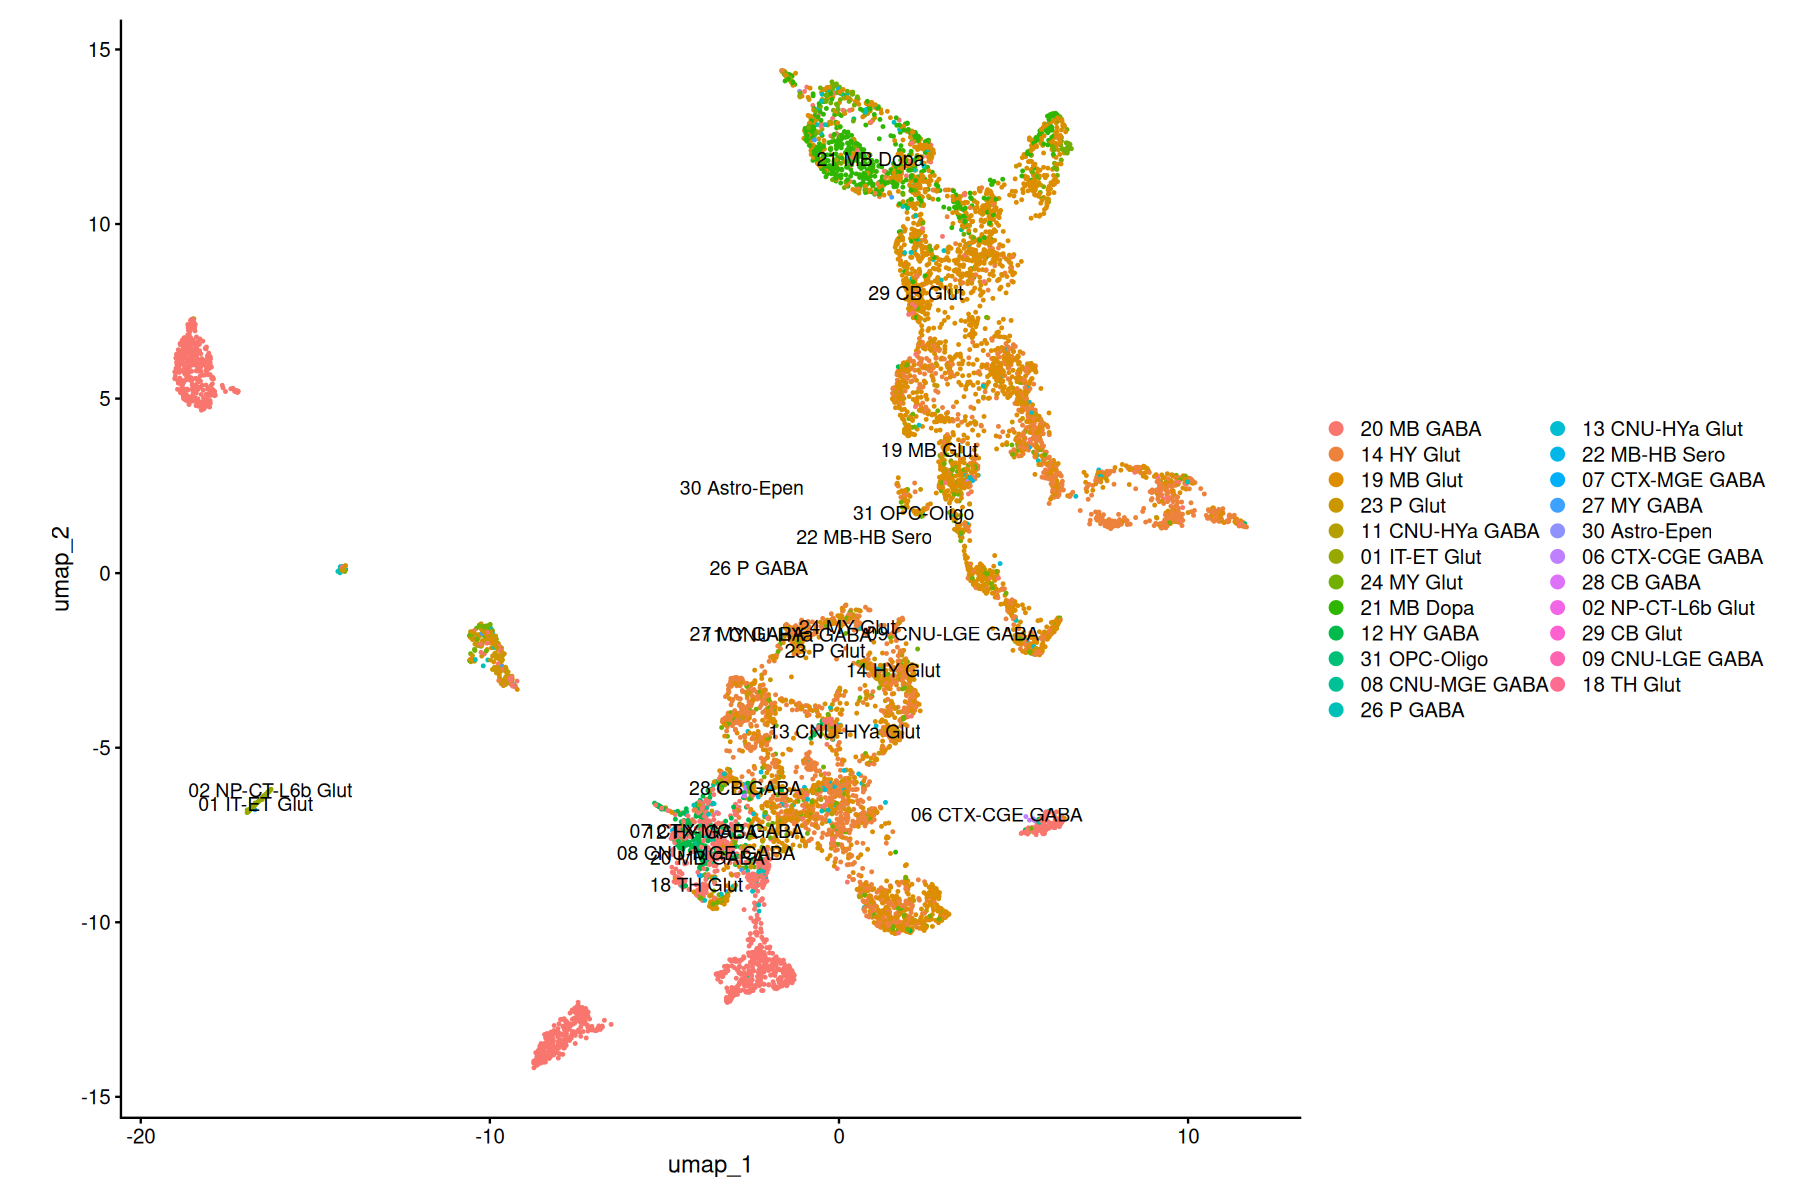

In [8]:
options(repr.plot.width=15, repr.plot.height=10)
Idents(neuron_2) <- 'Mouse_anno'
DimPlot(neuron_2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

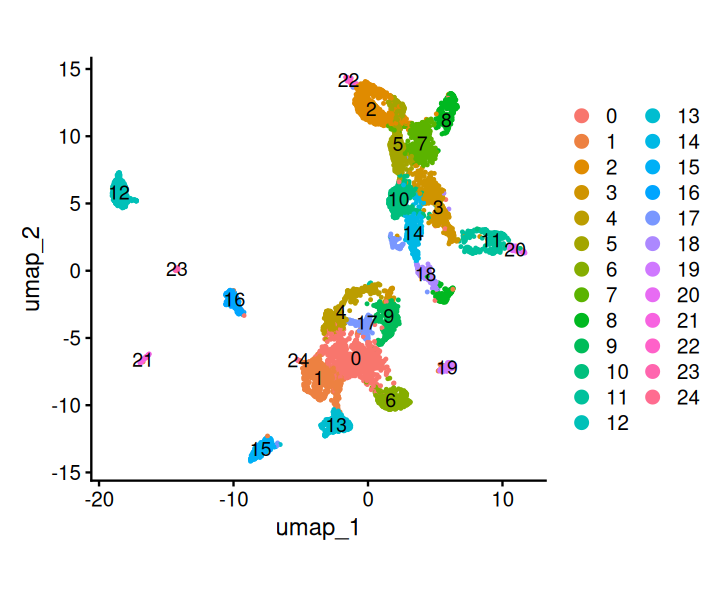

In [9]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_2) <- 'seurat_clusters'
DimPlot(neuron_2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

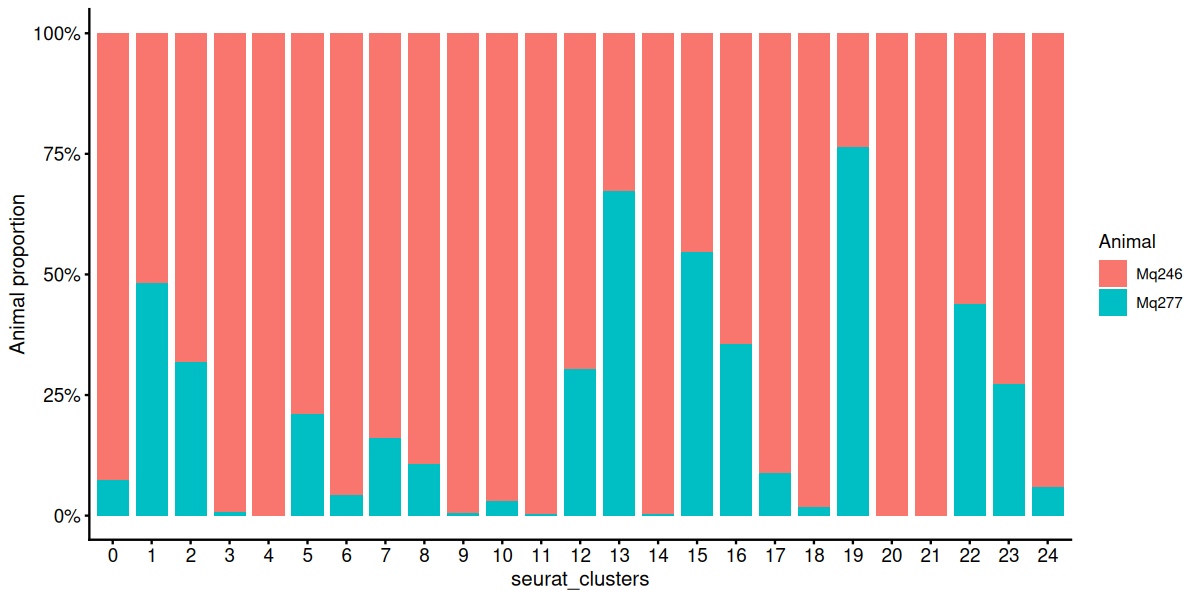

In [11]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- neuron_2@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [ ]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_2) <- 'seurat_clusters'
DimPlot(neuron_2, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [ ]:
neuron_3 = subset(neuron_2, !(seurat_clusters %in% c(3,4,9,10,11,14,18,20,21,23,24)))
neuron_3

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

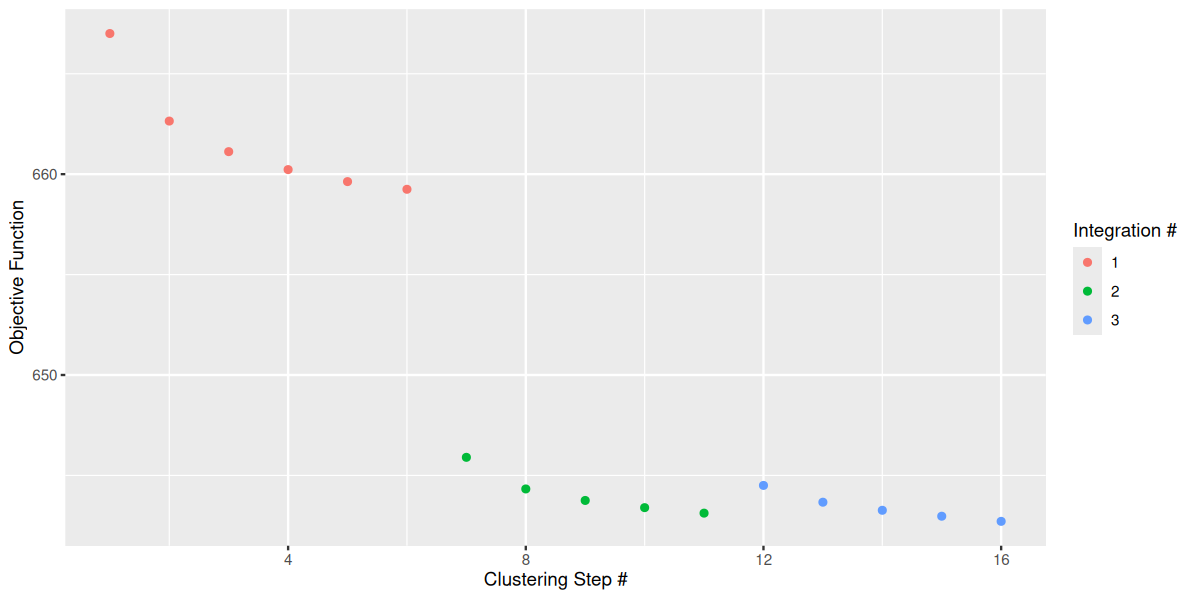

In [14]:
class_resolution = 0.3

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")
neuron_4 = neuron_3

assay = neuron_4@assays$RNA$counts
meta = neuron_4@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_4 = CreateSeuratObject(counts = new_assay)
neuron_4 = AddMetaData(neuron_4, meta)

neuron_4 = NormalizeData(neuron_4, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_4 = FindVariableFeatures(neuron_4, selection.method = "vst", nfeatures = 3000)
neuron_4 = ScaleData(neuron_4, features = rownames(neuron_4))

neuron_4 = neuron_4 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

neuron_4 = RunHarmony(
    neuron_4, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

neuron_4 = neuron_4 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

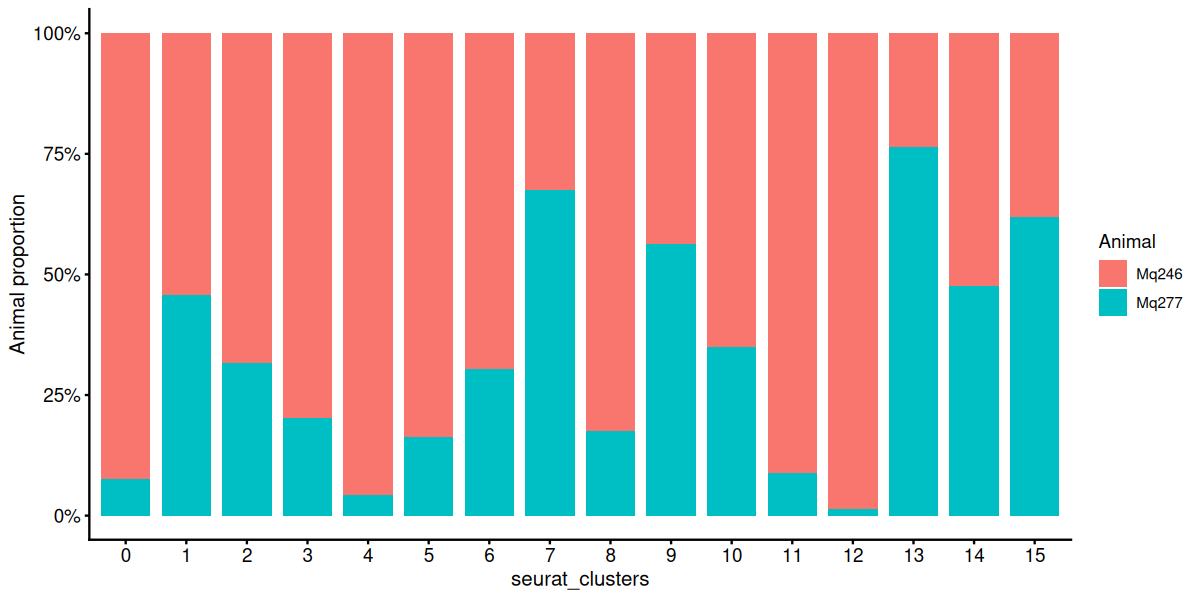

In [15]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- neuron_4@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [17]:
table(neuron_4$Mouse_anno, neuron_4$seurat_clusters)

                 
                    0   1   2   3   4   5   6   7   8   9  10  11  12  13  14
  06 CTX-CGE GABA   3   6   0   0   0   0   0   0   0   0   0   0   0   0   0
  07 CTX-MGE GABA   0   6   0   0   0   0   0   0   0   0   0   0   0   0   0
  08 CNU-MGE GABA   1  17   0   0   0   0   0   0   0   0   0   0   0   1   0
  09 CNU-LGE GABA   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  11 CNU-HYa GABA  13  18  11   0   2   0   1   0   0   0   1   1   0   0  19
  12 HY GABA       18 195   0   0   1   0   0   0   0   0   0   6   0   0   0
  13 CNU-HYa Glut  26   1   0   0   0   0   0   0   0   0   1   0   4   0   0
  14 HY Glut      467  14  12   8 182  33   0   0   4   0   1  50  41   0   2
  18 TH Glut        0   1   0   0   0   0   0   0   0   0   0   0   0   0   0
  19 MB Glut      312  78 163 363 237 321   0   0 180   0  35 105  86   1  17
  20 MB GABA       48 320  18  20   3   5 357 340   0 281  29  16   2 110   2
  21 MB Dopa        2   0 334  73   3  48   0 

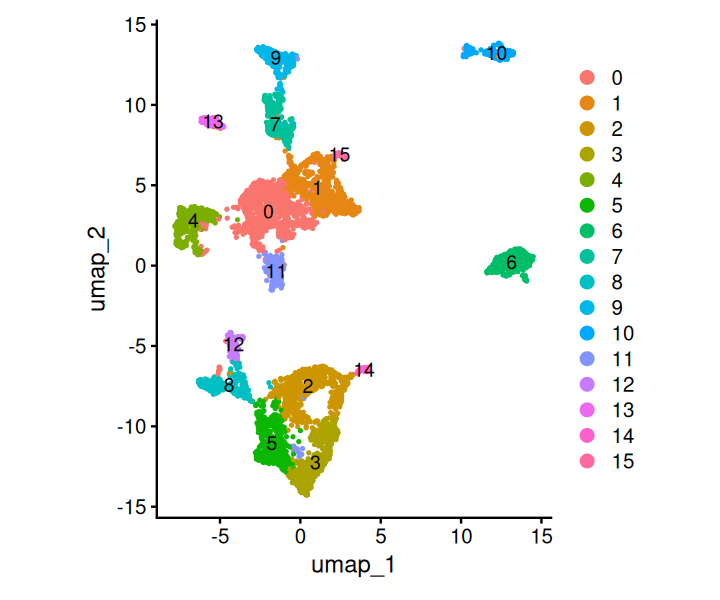

In [16]:
options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_4) <- 'seurat_clusters'
DimPlot(neuron_4, reduction="umap", label=T,raster=FALSE)+coord_fixed()

In [18]:
neuron_5 = subset(neuron_4, !(seurat_clusters %in% c(4,12)))
neuron_5

An object of class Seurat 
20344 features across 5229 samples within 1 assay 
Active assay: RNA (20344 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

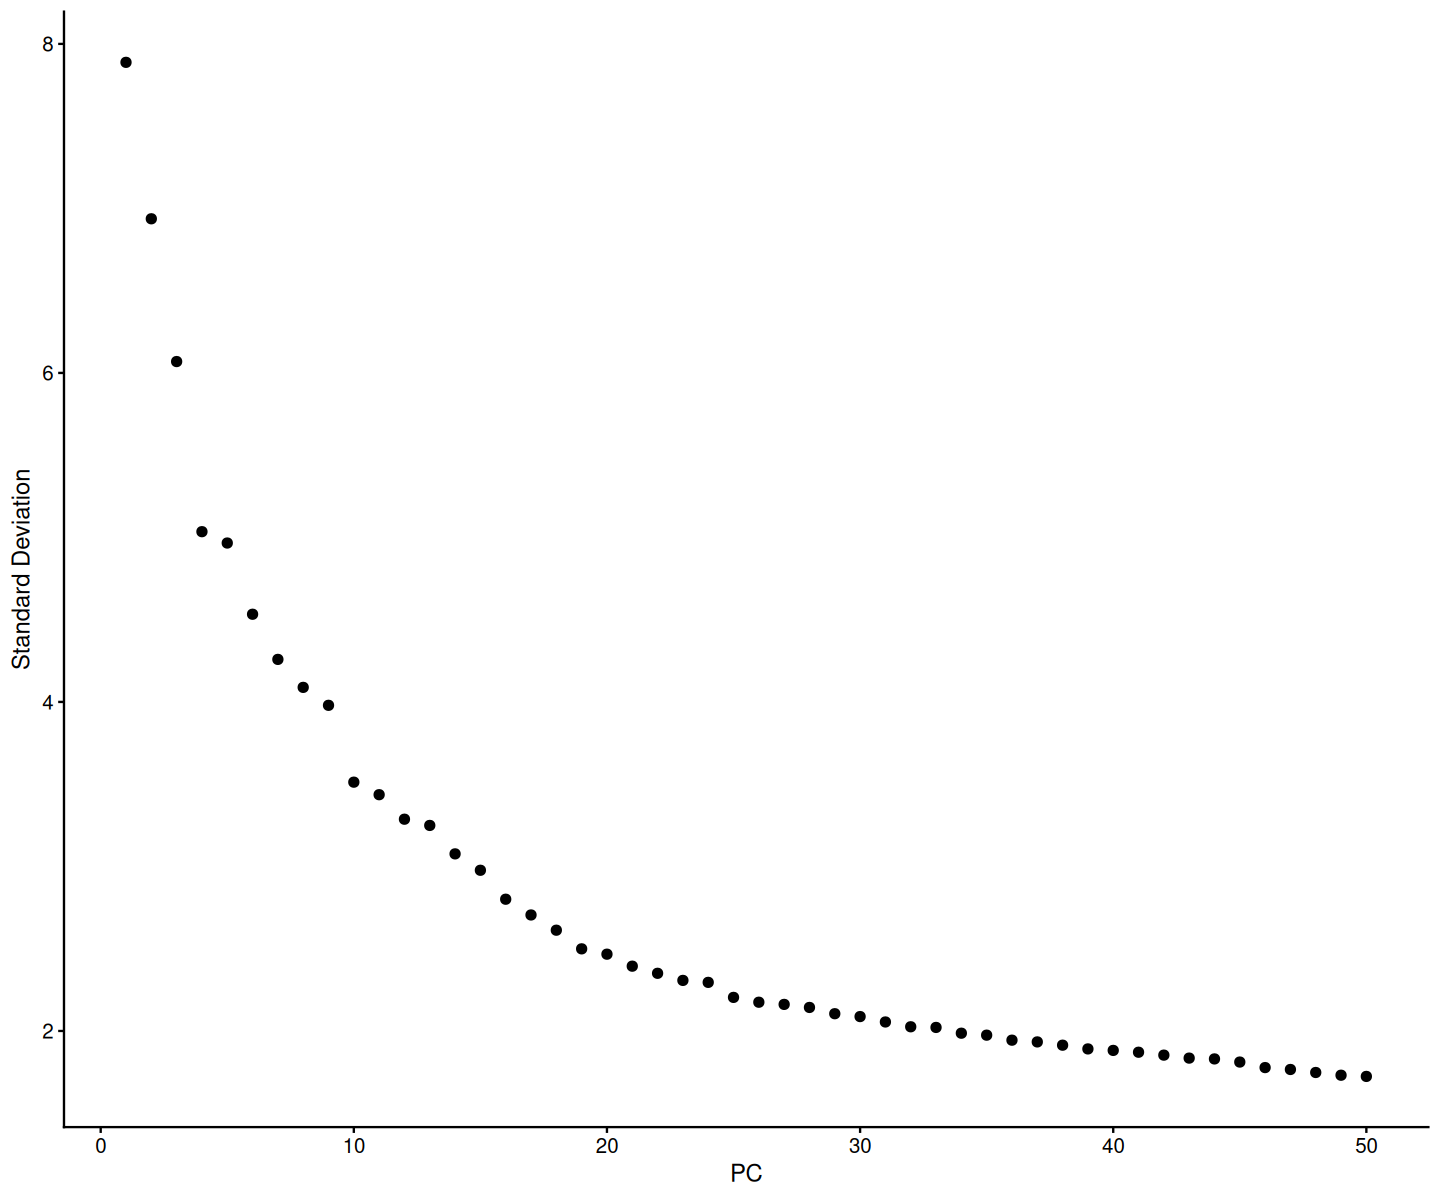

In [37]:
ElbowPlot(neuron_5, ndims = 50)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers w

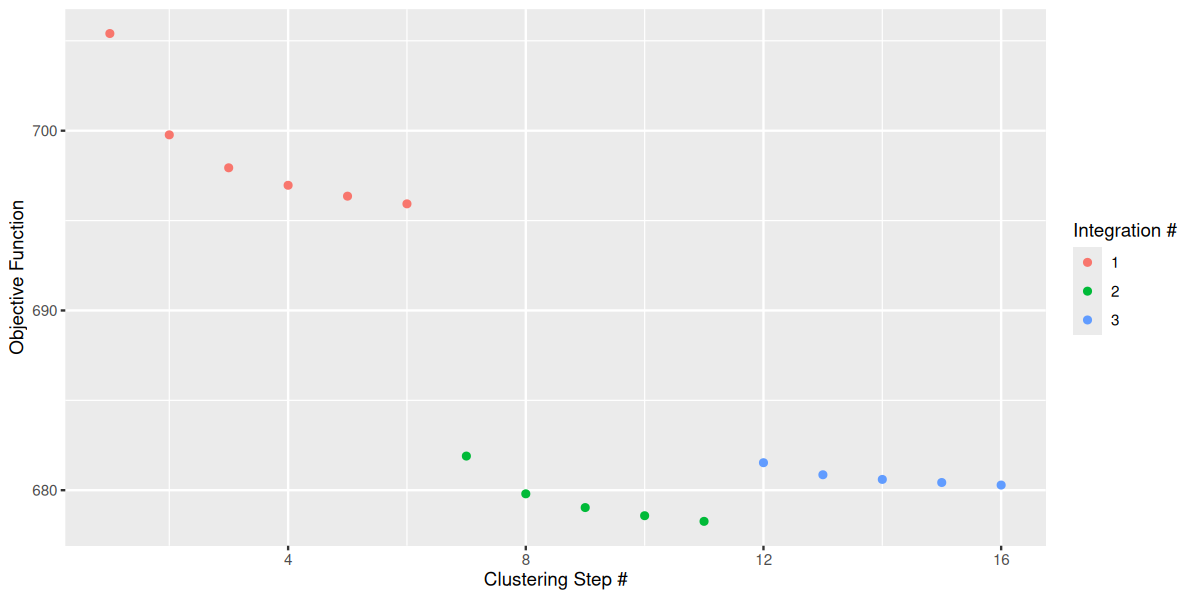

In [109]:
class_resolution = 0.2

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

assay = neuron_5@assays$RNA$counts
meta = neuron_5@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

neuron_6 = CreateSeuratObject(counts = new_assay)
neuron_6 = AddMetaData(neuron_6, meta)

neuron_6 = NormalizeData(neuron_6, normalization.method = "LogNormalize", scale.factor = 10000)
neuron_6 = FindVariableFeatures(neuron_6, selection.method = "vst", nfeatures = 3000)
neuron_6 = ScaleData(neuron_6, features = rownames(neuron_6))

neuron_6 = neuron_6 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:30, umap.method = "umap-learn")

neuron_6 = RunHarmony(
    neuron_6, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:30,
    theta = 2
)

neuron_6 = neuron_6 %>%
    FindNeighbors(reduction = "harmony", dims = 1:30) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:30)

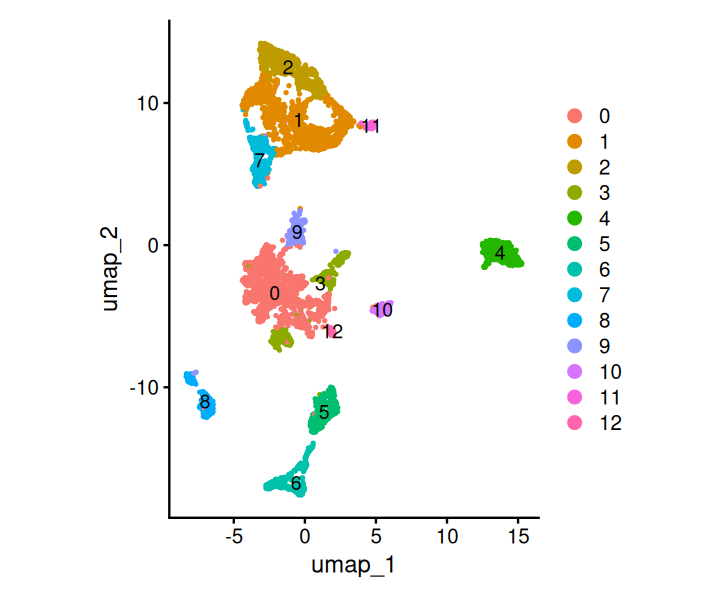

In [110]:

options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_6) <- 'seurat_clusters'
DimPlot(neuron_6, reduction="umap", label=T,raster=FALSE)+coord_fixed()

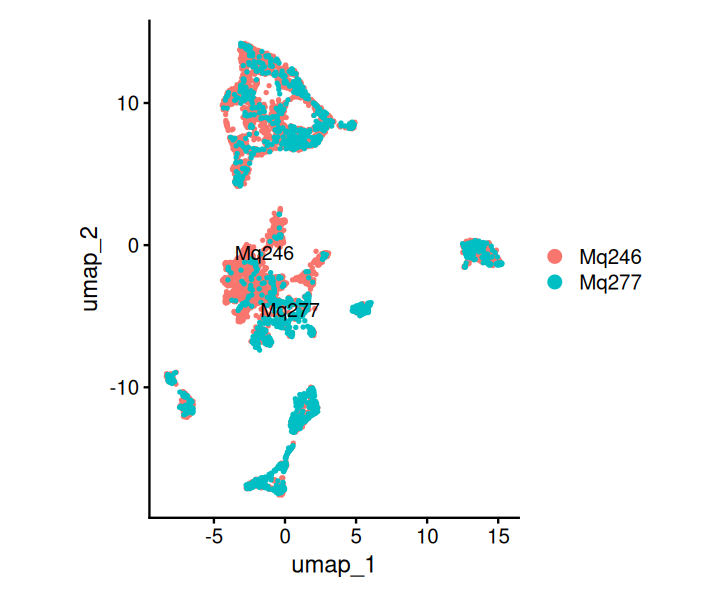

In [44]:

options(repr.plot.width=6, repr.plot.height=5)
Idents(neuron_6) <- 'Animal'
DimPlot(neuron_6, reduction="umap", label=T,raster=FALSE)+coord_fixed()

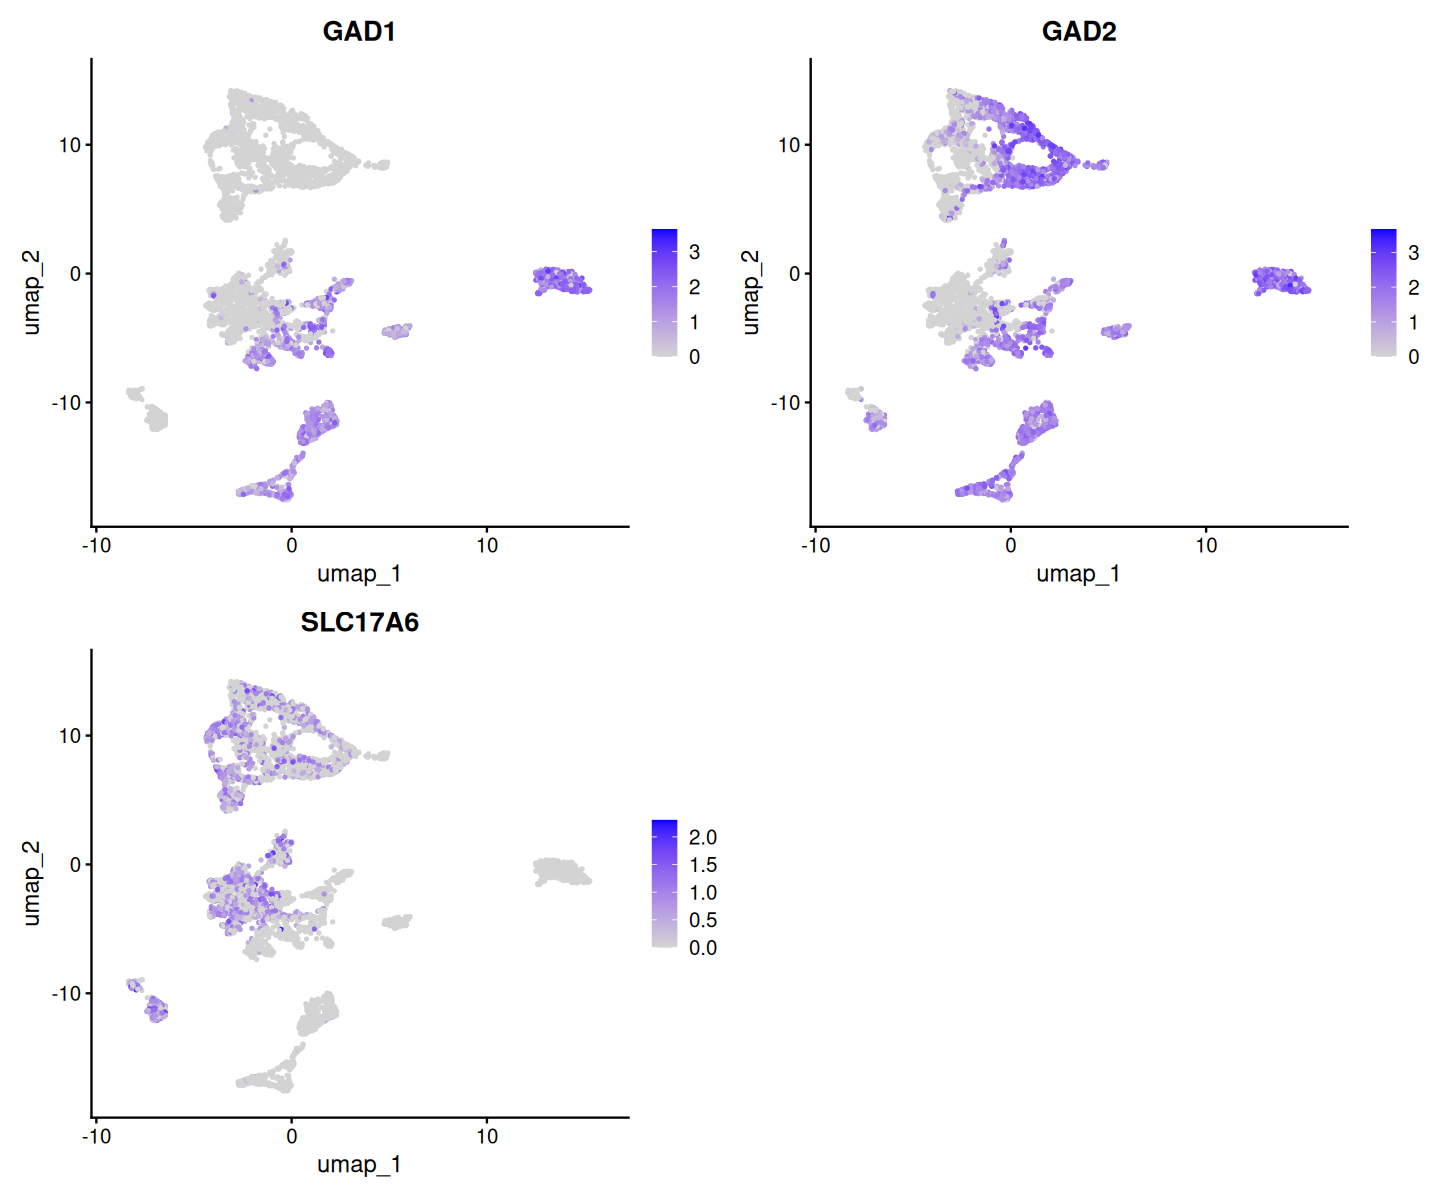

In [40]:
options(repr.plot.width=12, repr.plot.height=10)
FeaturePlot(neuron_6, features = c("GAD1","GAD2","SLC17A6"), ncol = 2, raster = FALSE)

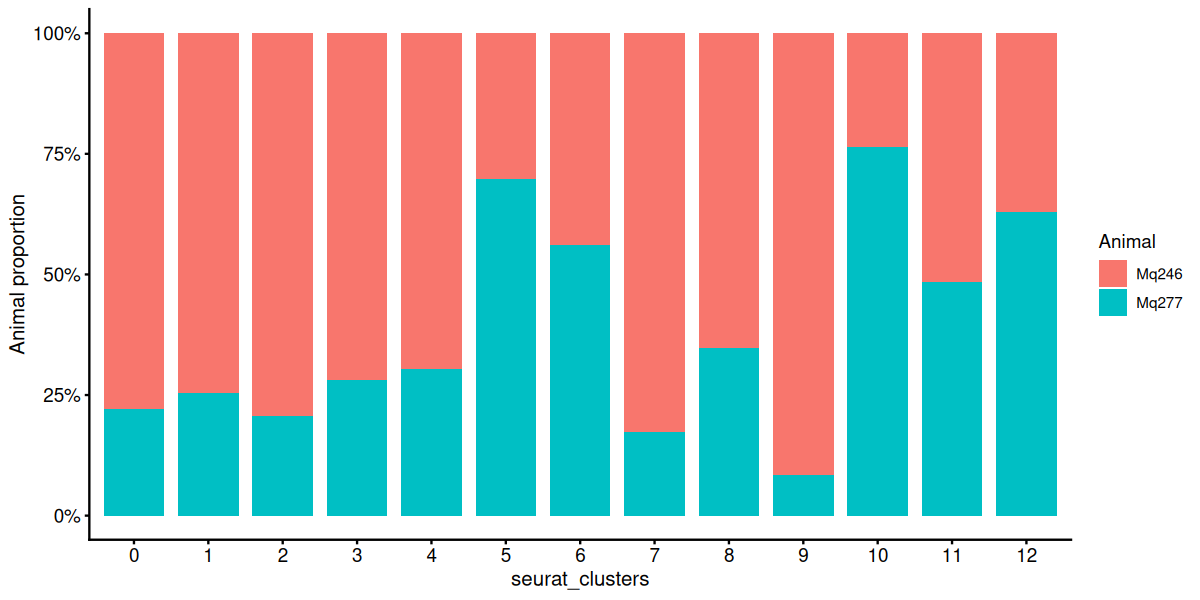

In [111]:
# 每个 Neuron seurat cluster 的 Animal 组成（比例堆积条形图）
cluster_animal_df <- neuron_6@meta.data %>%
    as.data.frame() %>%
    dplyr::count(seurat_clusters, Animal) %>%
    dplyr::group_by(seurat_clusters) %>%
    dplyr::mutate(proportion = n / sum(n)) %>%
    dplyr::ungroup()

options(repr.plot.width=10, repr.plot.height=5)
ggplot(cluster_animal_df, aes(x = factor(seurat_clusters), y = proportion, fill = Animal)) +
    geom_col(width = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(x = "seurat_clusters", y = "Animal proportion", fill = "Animal") +
    theme_classic() +
    theme(
        axis.text = element_text(size = 11),
        axis.title = element_text(size = 12)
    )

In [115]:
saveRDS(neuron_6, '/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260730_VTA_neuron.rds')

In [114]:
neuron_6$cluster = paste0('Neuron_', neuron_6$seurat_clusters)